# Phase 5: Ablation Experiments (Week 11)

Run complete ablation study across feature combinations and models.

Compare:
- Baseline features only
- + Weather features
- + Review embeddings
- + Both weather and embeddings

Using: Random Forest, Two-Tower

In [1]:
import sys
sys.path.insert(0, '../../')

import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from config import *
from src.models.random_forest import RandomForestRecommender
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("="*70)
print("PHASE 5: Ablation Experiments")
print("="*70)
print("\nTesting different feature combinations:")
print("  1. Baseline (user/dest features only)")
print("  2. + Weather")
print("  3. + Embeddings")
print("  4. + Both")
print("="*70)

PHASE 5: Ablation Experiments

Testing different feature combinations:
  1. Baseline (user/dest features only)
  2. + Weather
  3. + Embeddings
  4. + Both



Generating visualizations...


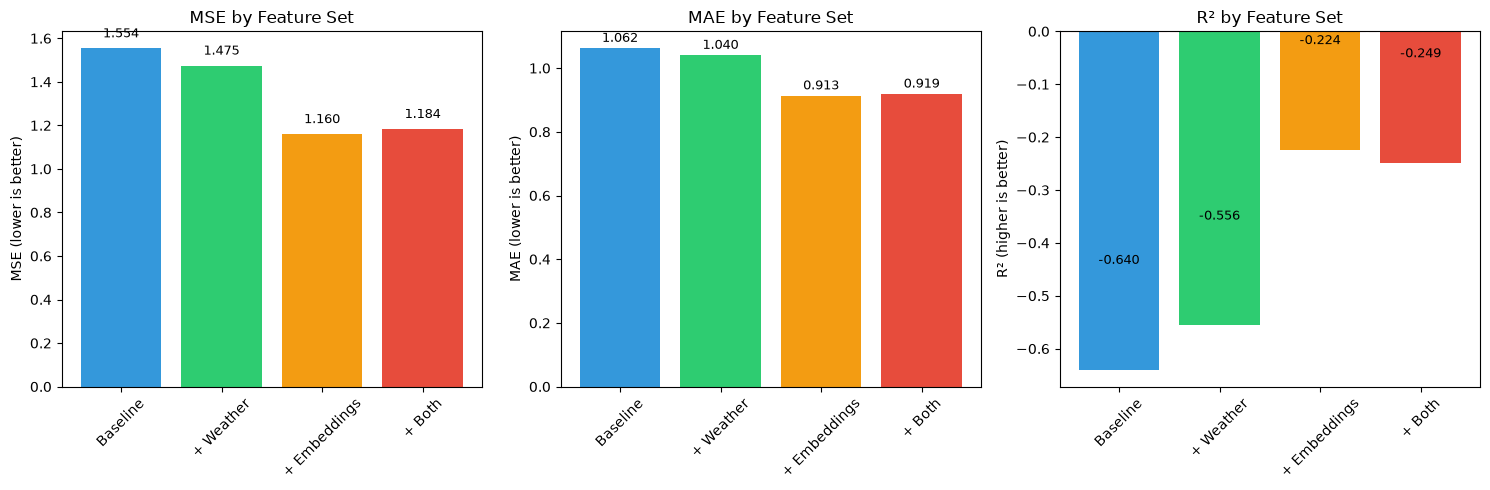


Saving results...
  ✓ Results saved to C:\Users\Marlene\OneDrive\Desktop\[Tume] ML course\ML Project\reports\phase5_ablation_results.csv

ABLATION ANALYSIS

Best configuration: + Embeddings
Best R² Score: -0.2242

Improvement from Baseline:
  + Weather           : +0.0837 (+13.1%)
  + Embeddings        : +0.4156 (+65.0%)
  + Both              : +0.3907 (+61.1%)

✅ PHASE 5 COMPLETE: Ablation Experiments


In [6]:
import matplotlib.pyplot as plt

print("\nGenerating visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MSE comparison
axes[0].bar(results_df.index, results_df['mse'], color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('MSE by Feature Set')
axes[0].set_ylabel('MSE (lower is better)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['mse']):
    axes[0].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=9)

# MAE comparison
axes[1].bar(results_df.index, results_df['mae'], color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('MAE by Feature Set')
axes[1].set_ylabel('MAE (lower is better)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['mae']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# R² comparison
axes[2].bar(results_df.index, results_df['r2'], color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[2].set_title('R² by Feature Set')
axes[2].set_ylabel('R² (higher is better)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(results_df['r2']):
    axes[2].text(i, v + 0.2, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Save results
print("\nSaving results...")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_path = REPORT_DIR / 'phase5_ablation_results.csv'
results_df.to_csv(results_path)
print(f"  ✓ Results saved to {results_path}")

# Analysis
print(f"\n{'='*70}")
print("ABLATION ANALYSIS")
print(f"{'='*70}")

best_scenario = results_df['r2'].idxmax()
best_r2 = results_df['r2'].max()

print(f"\nBest configuration: {best_scenario}")
print(f"Best R² Score: {best_r2:.4f}")

# Calculate improvements
baseline_r2 = results_df.loc['Baseline', 'r2']
print(f"\nImprovement from Baseline:")
for scenario in results_df.index[1:]:
    improvement = results_df.loc[scenario, 'r2'] - baseline_r2
    pct_improvement = (improvement / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
    print(f"  {scenario:20s}: {improvement:+.4f} ({pct_improvement:+.1f}%)")

print(f"\n{'='*70}")
print("✅ PHASE 5 COMPLETE: Ablation Experiments")
print(f"{'='*70}")

## Step 4: Visualize and Save Results

In [5]:
print("\nTraining Random Forest models for each configuration...")

results = {}
scenarios = [
    ("Baseline", X_train_baseline, y_train_baseline, X_test_baseline, y_test_baseline),
    ("+ Weather", X_train_weather, y_train_weather, X_test_weather, y_test_weather),
    ("+ Embeddings", X_train_emb, y_train_emb, X_test_emb, y_test_emb),
    ("+ Both", X_train_both, y_train_both, X_test_both, y_test_both)
]

for scenario_name, X_train, y_train, X_test, y_test in scenarios:
    print(f"\n{scenario_name}...")
    
    # Train model
    model = RandomForestRecommender(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        random_state=RF_RANDOM_STATE
    )
    model.train(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[scenario_name] = {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'n_features': X_train.shape[1]
    }
    
    print(f"  Features: {X_train.shape[1]}")
    print(f"  MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results).T
print(f"\n{'='*70}")
print("ABLATION STUDY RESULTS")
print(f"{'='*70}")
print(results_df.to_string())


Training Random Forest models for each configuration...

Baseline...
  Features: 7
  MSE: 1.5543, MAE: 1.0624, R²: -0.6397

+ Weather...
  Features: 36
  MSE: 1.4749, MAE: 1.0404, R²: -0.5560

+ Embeddings...
  Features: 775
  MSE: 1.1604, MAE: 0.9132, R²: -0.2242

+ Both...
  Features: 804
  MSE: 1.1839, MAE: 0.9187, R²: -0.2490

ABLATION STUDY RESULTS
                   mse       mae        r2  n_features
Baseline      1.554284  1.062371 -0.639742         7.0
+ Weather     1.474942  1.040441 -0.556037        36.0
+ Embeddings  1.160358  0.913168 -0.224157       775.0
+ Both        1.183940  0.918733 -0.249036       804.0


## Step 3: Train and Evaluate Each Configuration

In [4]:
print("\nBuilding feature sets for ablation study...")

def build_feature_matrix_with_exclusions(reviews_df, exclude_weather=False, exclude_embeddings=False):
    """Build feature matrix with optional feature exclusions."""
    features_list = []
    targets = []
    
    for idx, row in reviews_df.iterrows():
        user_id = row['user_id']
        city = row['city']
        rating = row['stars']
        
        # Baseline features: user avg_rating, rating_std, num_reviews, num_cities
        user_reviews = train_reviews_with_city[train_reviews_with_city['user_id'] == user_id]
        user_feat = {
            'user_avg_rating': user_reviews['stars'].mean(),
            'user_rating_std': user_reviews['stars'].std() or 0,
            'user_num_reviews': float(len(user_reviews)),
            'user_num_cities': float(user_reviews['city'].nunique())
        }
        
        # Destination baseline features
        city_reviews = train_reviews_with_city[train_reviews_with_city['city'] == city]
        city_businesses = businesses[businesses['city'] == city]
        
        dest_feat = {
            'dest_avg_rating': city_reviews['stars'].mean() if len(city_reviews) > 0 else 3.5,
            'dest_num_reviews': float(len(city_reviews)),
            'dest_num_businesses': float(len(city_businesses))
        }
        
        # Add weather if not excluded
        if not exclude_weather:
            weather_row = weather_features[weather_features['city'] == city]
            if not weather_row.empty:
                for col in weather_features.columns:
                    if col != 'city':
                        dest_feat[f'dest_{col}'] = float(weather_row[col].values[0])
        
        # Add embeddings if not excluded
        feature_vec = {**user_feat, **dest_feat}
        
        if not exclude_embeddings:
            # User embedding
            if user_id in user_embeddings:
                emb = user_embeddings[user_id]
                for i, val in enumerate(emb):
                    feature_vec[f'user_emb_{i}'] = float(val)
            else:
                for i in range(384):
                    feature_vec[f'user_emb_{i}'] = 0.0
            
            # Destination embedding
            if city in dest_embeddings:
                emb = dest_embeddings[city]
                for i, val in enumerate(emb):
                    feature_vec[f'dest_emb_{i}'] = float(val)
            else:
                for i in range(384):
                    feature_vec[f'dest_emb_{i}'] = 0.0
        
        features_list.append(feature_vec)
        targets.append(rating)
    
    X = pd.DataFrame(features_list).fillna(0)
    y = np.array(targets)
    return X.values, y

# Build feature sets for each scenario
print("\n1. Baseline (user/dest features only)...")
X_train_baseline, y_train_baseline = build_feature_matrix_with_exclusions(
    train_reviews_with_city, exclude_weather=True, exclude_embeddings=True
)
X_test_baseline, y_test_baseline = build_feature_matrix_with_exclusions(
    test_reviews_with_city, exclude_weather=True, exclude_embeddings=True
)
print(f"   Train: {X_train_baseline.shape}, Test: {X_test_baseline.shape}")

print("2. + Weather...")
X_train_weather, y_train_weather = build_feature_matrix_with_exclusions(
    train_reviews_with_city, exclude_weather=False, exclude_embeddings=True
)
X_test_weather, y_test_weather = build_feature_matrix_with_exclusions(
    test_reviews_with_city, exclude_weather=False, exclude_embeddings=True
)
print(f"   Train: {X_train_weather.shape}, Test: {X_test_weather.shape}")

print("3. + Embeddings...")
X_train_emb, y_train_emb = build_feature_matrix_with_exclusions(
    train_reviews_with_city, exclude_weather=True, exclude_embeddings=False
)
X_test_emb, y_test_emb = build_feature_matrix_with_exclusions(
    test_reviews_with_city, exclude_weather=True, exclude_embeddings=False
)
print(f"   Train: {X_train_emb.shape}, Test: {X_test_emb.shape}")

print("4. + Both (Weather + Embeddings)...")
X_train_both, y_train_both = build_feature_matrix_with_exclusions(
    train_reviews_with_city, exclude_weather=False, exclude_embeddings=False
)
X_test_both, y_test_both = build_feature_matrix_with_exclusions(
    test_reviews_with_city, exclude_weather=False, exclude_embeddings=False
)
print(f"   Train: {X_train_both.shape}, Test: {X_test_both.shape}")


Building feature sets for ablation study...

1. Baseline (user/dest features only)...
   Train: (221, 7), Test: (77, 7)
2. + Weather...
   Train: (221, 36), Test: (77, 36)
3. + Embeddings...
   Train: (221, 775), Test: (77, 775)
4. + Both (Weather + Embeddings)...
   Train: (221, 804), Test: (77, 804)


## Step 2: Build Feature Sets for Each Ablation Scenario

In [3]:
print("\nLoading Phase 4 data and model...")

# Load reviews
train_reviews = pd.read_parquet(CACHE_DIR / 'train_reviews.parquet')
test_reviews = pd.read_parquet(CACHE_DIR / 'test_reviews.parquet')
businesses = pd.read_parquet(CACHE_DIR / 'businesses_major_cities.parquet')

# Load features
weather_features = pd.read_parquet(CACHE_DIR / 'weather_features_for_models.parquet')
dest_embeddings = joblib.load(CACHE_DIR / 'destination_embeddings.joblib')
user_embeddings = joblib.load(CACHE_DIR / 'user_embeddings.joblib')

# Load trained Random Forest model
rf_model = joblib.load(OUTPUT_DIR / 'random_forest_model.joblib')

print(f"  ✓ Loaded {len(train_reviews)} train reviews")
print(f"  ✓ Loaded {len(test_reviews)} test reviews")
print(f"  ✓ Loaded Random Forest model")

# Merge reviews with city info
train_reviews_with_city = train_reviews.merge(
    businesses[['business_id', 'city']], on='business_id', how='left'
)
test_reviews_with_city = test_reviews.merge(
    businesses[['business_id', 'city']], on='business_id', how='left'
)


Loading Phase 4 data and model...
  ✓ Loaded 221 train reviews
  ✓ Loaded 77 test reviews
  ✓ Loaded Random Forest model


## Step 1: Load Data and Trained Model